In [81]:
!pip install scikit-fuzzy

# 1. Imports

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, f1_score

# 2. Explore Data

In [83]:
# Read CSV
df = pd.read_csv('AMT Anomaly Dataset.csv')

In [84]:
# Check data types for the membership functions later (number of records)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              60 non-null     int64  
 1   delay_ms        60 non-null     int64  
 2   clutch_temp_c   60 non-null     int64  
 3   torque_var_pct  60 non-null     float64
 4   rpm_diff        60 non-null     int64  
 5   severity        60 non-null     object 
 6   action          60 non-null     object 
dtypes: float64(1), int64(4), object(2)
memory usage: 3.4+ KB


In [85]:
# Describe dataset for min and max values for later reference
df.describe()

,id,delay_ms,clutch_temp_c,torque_var_pct,rpm_diff
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,30.500000,113.600000,105.333333,5.771667,100.466667
std,17.464249,28.049714,12.260819,2.758413,39.521917
min,1.000000,66.000000,85.000000,1.700000,34.000000
25%,15.750000,95.000000,97.000000,4.100000,75.750000
50%,30.500000,105.000000,102.000000,5.050000,87.000000
75%,45.250000,132.750000,111.250000,6.325000,120.000000
max,60.000000,188.000000,138.000000,14.100000,210.000000


In [86]:
# Typical normal severity values
df[df["severity"] == "Normal"]

,id,delay_ms,clutch_temp_c,torque_var_pct,rpm_diff,severity,action
0,1,72,86,2.1,45,Normal,NO_ACTION
1,2,88,92,3.8,62,Normal,NO_ACTION
2,3,95,98,4.9,79,Normal,NO_ACTION
3,4,66,90,1.7,34,Normal,NO_ACTION
4,5,101,94,5.0,80,Normal,NO_ACTION
5,6,78,85,2.9,58,Normal,NO_ACTION
6,7,92,99,4.2,83,Normal,NO_ACTION
7,8,84,93,3.1,55,Normal,NO_ACTION
8,9,105,100,4.8,88,Normal,NO_ACTION
9,10,97,89,2.6,71,Normal,NO_ACTION


In [87]:
# Typical moderate values
df[df["severity"] == "Moderate"]

,id,delay_ms,clutch_temp_c,torque_var_pct,rpm_diff,severity,action
10,11,118,96,4.5,72,Moderate,SHIFT_TIMING_ADJUST
11,12,132,101,3.9,66,Moderate,SHIFT_TIMING_ADJUST
12,13,145,103,5.4,82,Moderate,SHIFT_TIMING_ADJUST
13,14,112,97,5.2,76,Moderate,SHIFT_TIMING_ADJUST
14,15,155,104,4.7,85,Moderate,SHIFT_TIMING_ADJUST
15,16,98,109,3.2,70,Moderate,TORQUE_REDISTRIBUTION
16,17,102,111,4.1,78,Moderate,TORQUE_REDISTRIBUTION
17,18,95,118,2.7,65,Moderate,TORQUE_REDISTRIBUTION
18,19,106,120,5.0,86,Moderate,TORQUE_REDISTRIBUTION
19,20,88,107,4.6,80,Moderate,TORQUE_REDISTRIBUTION


In [88]:
# Typical severe values
df[df["severity"] == "Severe"]

,id,delay_ms,clutch_temp_c,torque_var_pct,rpm_diff,severity,action
30,31,165,104,5.9,85,Severe,SHIFT_TIMING_ADJUST
31,32,172,99,4.1,70,Severe,SHIFT_TIMING_ADJUST
32,33,160,101,3.8,92,Severe,SHIFT_TIMING_ADJUST
33,34,188,110,6.0,120,Severe,TORQUE_REDISTRIBUTION
34,35,175,119,7.2,150,Severe,TORQUE_REDISTRIBUTION
35,36,108,127,4.3,84,Severe,CLUTCH_PRESSURE_RECALIB
36,37,120,132,5.2,96,Severe,CLUTCH_PRESSURE_RECALIB
37,38,98,125,3.1,70,Severe,CLUTCH_PRESSURE_RECALIB
38,39,142,138,6.4,110,Severe,CLUTCH_PRESSURE_RECALIB
39,40,156,130,9.0,140,Severe,CLUTCH_PRESSURE_RECALIB


# 3. Define Variables

In [89]:
# Define input variables and their column names
variables = {
    'delay': 'delay_ms',
    'temperature': 'clutch_temp_c',
    'torque': 'torque_var_pct',
    'rpm': 'rpm_diff'
}

# Severity levels in order
severities = ['Normal', 'Moderate', 'Severe']

# Store results
membership_params = {}

for var_name, col in variables.items():

    params_for_var = {}

    for sev in severities:
        # Filter data for this severity
        data = df[df['severity'] == sev][col]

        # Calculate percentiles for skewed data
        a = np.percentile(data, 10)
        b = np.percentile(data, 50)
        c = np.percentile(data, 90)

        # Round for cleanliness
        a, b, c = round(a, 1), round(b, 1), round(c, 1)

        params_for_var[sev.lower()] = (a, b, c)

    membership_params[var_name] = params_for_var

# Print the membership function
for var_name, sev_dict in membership_params.items():
    print(f"\n# {var_name.title()} membership functions")
    for sev, (a,b,c) in sev_dict.items():
        match sev:
          case "normal":
            sev = "low"
          case "moderate":
            sev = "medium"
          case "severe":
            sev = "high"
        print(f"{var_name}['{sev}'] = fuzz.trimf({var_name}.universe, [{a}, {b}, {c}])")


# Delay membership functions
delay['low'] = fuzz.trimf(delay.universe, [72.4, 90.0, 100.6])
delay['medium'] = fuzz.trimf(delay.universe, [90.0, 103.0, 135.0])
delay['high'] = fuzz.trimf(delay.universe, [98.7, 137.5, 171.3])

# Temperature membership functions
temperature['low'] = fuzz.trimf(temperature.universe, [86.2, 92.5, 98.9])
temperature['medium'] = fuzz.trimf(temperature.universe, [96.0, 101.5, 116.0])
temperature['high'] = fuzz.trimf(temperature.universe, [100.1, 111.0, 129.9])

# Torque membership functions
torque['low'] = fuzz.trimf(torque.universe, [2.1, 3.4, 4.9])
torque['medium'] = fuzz.trimf(torque.universe, [3.8, 5.2, 8.6])
torque['high'] = fuzz.trimf(torque.universe, [4.0, 6.1, 12.1])

# Rpm membership functions
rpm['low'] = fuzz.trimf(rpm.universe, [46.0, 66.5, 82.7])
rpm['medium'] = fuzz.trimf(rpm.universe, [71.0, 85.5, 127.5])
rpm['high'] = fuzz.trimf(rpm.universe, [84.1, 125.0, 184.0])


In [90]:
# Define antecedents
delay = ctrl.Antecedent(np.arange(df['delay_ms'].min(),df['delay_ms'].max(),1),'delay')
temperature = ctrl.Antecedent(np.arange(df['clutch_temp_c'].min() ,df['clutch_temp_c'].max(),1),'temperature')
torque = ctrl.Antecedent(np.arange(df['torque_var_pct'].min() ,df['torque_var_pct'].max(),0.1),'torque')
rpm = ctrl.Antecedent(np.arange(df['rpm_diff'].min(), df['rpm_diff'].max() ,1),'rpm')

In [91]:
# # Delay membership functions
# delay['low'] = fuzz.trimf(delay.universe, [72.4, 90.0, 100.6])
# delay['medium'] = fuzz.trimf(delay.universe, [90.0, 103.0, 135.0])
# delay['high'] = fuzz.trimf(delay.universe, [98.7, 137.5, 171.3])

# # Temperature membership functions
# temperature['low'] = fuzz.trimf(temperature.universe, [86.2, 92.5, 98.9])
# temperature['medium'] = fuzz.trimf(temperature.universe, [96.0, 101.5, 116.0])
# temperature['high'] = fuzz.trimf(temperature.universe, [100.1, 111.0, 129.9])

# # Torque membership functions
# torque['low'] = fuzz.trimf(torque.universe, [2.1, 3.4, 4.9])
# torque['medium'] = fuzz.trimf(torque.universe, [3.8, 5.2, 8.6])
# torque['high'] = fuzz.trimf(torque.universe, [4.0, 6.1, 12.1])

# # Rpm membership functions
# rpm['low'] = fuzz.trimf(rpm.universe, [46.0, 66.5, 82.7])
# rpm['medium'] = fuzz.trimf(rpm.universe, [71.0, 85.5, 127.5])
# rpm['high'] = fuzz.trimf(rpm.universe, [84.1, 125.0, 184.0])

In [92]:
# Create trapezoidal membership functions
trap_params = {}

for var_name, col in variables.items():
    global_min = df[col].min()
    global_max = df[col].max()
    params_for_var = {}

    # Loop the severities
    for sev in severities:
        data = df[df['severity'] == sev][col]
        p10 = np.percentile(data, 10)
        p50 = np.percentile(data, 50)
        p90 = np.percentile(data, 90)
        if sev == 'Normal':
            a, b, c, d = global_min, p10, p50, p50
        elif sev == 'Moderate':
            a, b, c, d = p10, p50, p90, p90
        else:  # Severe
            a, b, c, d = p50, p90, global_max, global_max
        params_for_var[sev.lower()] = (a, b, c, d)
    trap_params[var_name] = params_for_var

# Print them
for var_name, sev_dict in trap_params.items():
    print(f"\n# {var_name.title()} trapezoidal membership functions")
    for sev, (a,b,c,d) in sev_dict.items():
        match sev:
          case "normal":
            sev = "low"
          case "moderate":
            sev = "medium"
          case "severe":
            sev = "high"
        print(f"{var_name}['{sev}'] = fuzz.trapmf({var_name}.universe, [{a:.1f}, {b:.1f}, {c:.1f}, {d:.1f}])")


# Delay trapezoidal membership functions
delay['low'] = fuzz.trapmf(delay.universe, [66.0, 72.4, 90.0, 90.0])
delay['medium'] = fuzz.trapmf(delay.universe, [90.0, 103.0, 135.0, 135.0])
delay['high'] = fuzz.trapmf(delay.universe, [137.5, 171.3, 188.0, 188.0])

# Temperature trapezoidal membership functions
temperature['low'] = fuzz.trapmf(temperature.universe, [85.0, 86.2, 92.5, 92.5])
temperature['medium'] = fuzz.trapmf(temperature.universe, [96.0, 101.5, 116.0, 116.0])
temperature['high'] = fuzz.trapmf(temperature.universe, [111.0, 129.9, 138.0, 138.0])

# Torque trapezoidal membership functions
torque['low'] = fuzz.trapmf(torque.universe, [1.7, 2.1, 3.5, 3.5])
torque['medium'] = fuzz.trapmf(torque.universe, [3.8, 5.2, 8.6, 8.6])
torque['high'] = fuzz.trapmf(torque.universe, [6.1, 12.1, 14.1, 14.1])

# Rpm trapezoidal membership functions
rpm['low'] = fuzz.trapmf(rpm.universe, [34.0, 46.0, 66.5, 66.5])
rpm['medium'] = fuzz.trapmf(rpm.universe, [71.0, 85.5, 127.5, 127.5])
rpm['high'] 

In [93]:
# # Delay trapezoidal membership functions
# delay['low'] = fuzz.trapmf(delay.universe, [66.0, 72.4, 90.0, 90.0])
# delay['medium'] = fuzz.trapmf(delay.universe, [90.0, 103.0, 135.0, 135.0])
# delay['high'] = fuzz.trapmf(delay.universe, [137.5, 171.3, 188.0, 188.0])

# # Temperature trapezoidal membership functions
# temperature['low'] = fuzz.trapmf(temperature.universe, [85.0, 86.2, 92.5, 92.5])
# temperature['medium'] = fuzz.trapmf(temperature.universe, [96.0, 101.5, 116.0, 116.0])
# temperature['high'] = fuzz.trapmf(temperature.universe, [111.0, 129.9, 138.0, 138.0])

# # Torque trapezoidal membership functions
# torque['low'] = fuzz.trapmf(torque.universe, [1.7, 2.1, 3.5, 3.5])
# torque['medium'] = fuzz.trapmf(torque.universe, [3.8, 5.2, 8.6, 8.6])
# torque['high'] = fuzz.trapmf(torque.universe, [6.1, 12.1, 14.1, 14.1])

# # Rpm trapezoidal membership functions
# rpm['low'] = fuzz.trapmf(rpm.universe, [34.0, 46.0, 66.5, 66.5])
# rpm['medium'] = fuzz.trapmf(rpm.universe, [71.0, 85.5, 127.5, 127.5])
# rpm['high'] = fuzz.trapmf(rpm.universe, [125.0, 184.0, 210.0, 210.0])

In [94]:
# Gaussian membership functions
gauss_params = {}

for var_name, col in variables.items():
    params_for_var = {}
    for sev in severities:
        data = df[df['severity'] == sev][col]
        p50 = np.percentile(data, 50)
        mean = p50
        sigma = data.std()
        params_for_var[sev.lower()] = (mean, sigma)
    gauss_params[var_name] = params_for_var

# Print them
for var_name, sev_dict in gauss_params.items():
    print(f"\n# {var_name.title()} Gaussian membership functions")
    for sev, (mean, sigma) in sev_dict.items():
        match sev:
          case "normal":
            sev = "low"
          case "moderate":
            sev = "medium"
          case "severe":
            sev = "high"
        print(f"{var_name}['{sev}'] = fuzz.gaussmf({var_name}.universe, {mean:.1f}, {sigma:.1f})")


# Delay Gaussian membership functions
delay['low'] = fuzz.gaussmf(delay.universe, 90.0, 12.1)
delay['medium'] = fuzz.gaussmf(delay.universe, 103.0, 17.8)
delay['high'] = fuzz.gaussmf(delay.universe, 137.5, 28.9)

# Temperature Gaussian membership functions
temperature['low'] = fuzz.gaussmf(temperature.universe, 92.5, 5.0)
temperature['medium'] = fuzz.gaussmf(temperature.universe, 101.5, 7.9)
temperature['high'] = fuzz.gaussmf(temperature.universe, 111.0, 12.4)

# Torque Gaussian membership functions
torque['low'] = fuzz.gaussmf(torque.universe, 3.5, 1.2)
torque['medium'] = fuzz.gaussmf(torque.universe, 5.2, 2.0)
torque['high'] = fuzz.gaussmf(torque.universe, 6.1, 3.3)

# Rpm Gaussian membership functions
rpm['low'] = fuzz.gaussmf(rpm.universe, 66.5, 16.4)
rpm['medium'] = fuzz.gaussmf(rpm.universe, 85.5, 25.8)
rpm['high'] = fuzz.gaussmf(rpm.universe, 125.0, 42.1)


In [95]:
# Delay Gaussian membership functions
delay['low'] = fuzz.gaussmf(delay.universe, 90.0, 12.1)
delay['medium'] = fuzz.gaussmf(delay.universe, 103.0, 17.8)
delay['high'] = fuzz.gaussmf(delay.universe, 137.5, 28.9)

# Temperature Gaussian membership functions
temperature['low'] = fuzz.gaussmf(temperature.universe, 92.5, 5.0)
temperature['medium'] = fuzz.gaussmf(temperature.universe, 101.5, 7.9)
temperature['high'] = fuzz.gaussmf(temperature.universe, 111.0, 12.4)

# Torque Gaussian membership functions
torque['low'] = fuzz.gaussmf(torque.universe, 3.5, 1.2)
torque['medium'] = fuzz.gaussmf(torque.universe, 5.2, 2.0)
torque['high'] = fuzz.gaussmf(torque.universe, 6.1, 3.3)

# Rpm Gaussian membership functions
rpm['low'] = fuzz.gaussmf(rpm.universe, 66.5, 16.4)
rpm['medium'] = fuzz.gaussmf(rpm.universe, 85.5, 25.8)
rpm['high'] = fuzz.gaussmf(rpm.universe, 125.0, 42.1)

In [96]:
# Add severity as input to action system
severity_output = ctrl.Consequent(np.arange(0,101,1), "severity")

severity_output['low'] = fuzz.trimf(severity_output.universe, [0,0,45])
severity_output['medium'] = fuzz.trimf(severity_output.universe, [30,55,75])
severity_output['high'] = fuzz.trimf(severity_output.universe, [65,100,100])

In [97]:
# Action membership function
action = ctrl.Consequent(np.arange(0,5,1), "action")

# Output
action['no_action'] = fuzz.trimf(action.universe, [0,0,1])
action['shift'] = fuzz.trimf(action.universe, [0.5,1,2])
action['clutch'] = fuzz.trimf(action.universe, [1.5,2,3])
action['torque'] = fuzz.trimf(action.universe, [2.5,3,4])
action['rpm'] = fuzz.trimf(action.universe, [3.5,4,4])

In [98]:
severity_input = ctrl.Antecedent(np.arange(0,101,1), "severity_input")

# Severity membership function
severity_input['low'] = fuzz.trimf(severity_input.universe, [0,0,40])
severity_input['medium'] = fuzz.trimf(severity_input.universe, [30,55,85])
severity_input['high'] = fuzz.trimf(severity_input.universe, [65,100,100])

# 4. Define Rules

In [99]:
# Define rule base
severity_rules = [

    # Low
    ctrl.Rule(delay['low'] & torque['low'], severity_output['low']),
    ctrl.Rule(rpm['low'] & temperature['low'], severity_output['low']),
    ctrl.Rule(delay['low'] & rpm['low'], severity_output['low']),

    # Medium
    ctrl.Rule(delay['medium'] & rpm['medium'], severity_output['medium']),
    ctrl.Rule(temperature['medium'] & torque['medium'], severity_output['medium']),
    ctrl.Rule(delay['medium'] & temperature['medium'], severity_output['medium']),
    ctrl.Rule(rpm["medium"] & temperature["medium"] & torque["medium"], severity_output["medium"]),

    # High
    ctrl.Rule(delay['high'], severity_output['high']),
    ctrl.Rule(rpm['high'], severity_output['high']),
    ctrl.Rule(delay['high'] & rpm['high'], severity_output['high']),
    ctrl.Rule(delay['high'] & temperature['high'], severity_output['high']),
    ctrl.Rule(temperature['high'] & torque['high'], severity_output['high']),
    ctrl.Rule(torque["high"] & rpm["high"], severity_output["high"])
]

action_rules = [

    # Low
    ctrl.Rule(severity_input['low'], action['no_action']),

    # Medium
    ctrl.Rule(severity_input['medium'] & delay['high'], action['shift']),
    ctrl.Rule(severity_input["medium"] & rpm["medium"] & torque["medium"], action["torque"]),
    ctrl.Rule(severity_input["medium"] & rpm["high"] & torque["high"], action["torque"]),
    ctrl.Rule(severity_input["medium"] & temperature["medium"] & torque["medium"] & rpm["medium"], action["torque"]),

    # High
    ctrl.Rule(severity_input['high'] & delay['high'], action['shift']),
    ctrl.Rule(severity_input['high'] & temperature['high'], action['clutch']),
    ctrl.Rule(severity_input['high'] & torque['high'], action['torque']),
    ctrl.Rule(severity_input['high'] & rpm['high'], action['rpm'])
]

In [100]:
# Defint the severity and action systems
severity_system = ctrl.ControlSystem(severity_rules)
action_system = ctrl.ControlSystem(action_rules)

# 5. Evaluate Fuzzy Logic

In [101]:
def fuzzy_action_to_class(value) -> str:
    """
    Converts a fuzzy value to a class label.

    Args:
      value: The fuzzy value to convert.

    Returns:
      The action class label.
    """
    memberships = {
        "NO_ACTION": fuzz.interp_membership(action.universe, action['no_action'].mf, value),
        "SHIFT_TIMING_ADJUST": fuzz.interp_membership(action.universe, action['shift'].mf, value),
        "CLUTCH_PRESSURE_RECALIB": fuzz.interp_membership(action.universe, action['clutch'].mf, value),
        "TORQUE_REDISTRIBUTION": fuzz.interp_membership(action.universe, action['torque'].mf, value),
        "RPM_SYNC": fuzz.interp_membership(action.universe, action['rpm'].mf, value),
    }
    return max(memberships, key=memberships.get)

In [102]:
def fuzzy_severity_to_class(value):
    """
    Converts a fuzzy severity value to a class label.

    Args:
      value: The fuzzy severity value to convert.

    Returns:
      The class severity label.
    """
    memberships = {
        "Normal": fuzz.interp_membership(severity_input.universe, severity_input['low'].mf, value),
        "Moderate": fuzz.interp_membership(severity_input.universe, severity_input['medium'].mf, value),
        "Severe": fuzz.interp_membership(severity_input.universe, severity_input['high'].mf, value),
    }
    return max(memberships, key=memberships.get)

In [103]:
# True and predicted predictions
y_true = df["severity"].values

In [104]:
# Store predictions for later evaluation
severity_pred = []
action_pred = []

start = time.time()

# Loop through each record
for i in range(len(df)):

    # Severity system
    sim1 = ctrl.ControlSystemSimulation(severity_system)

    sim1.input['temperature'] = df.loc[i, "clutch_temp_c"]
    sim1.input['torque'] = df.loc[i, "torque_var_pct"]
    sim1.input['delay'] = df.loc[i, "delay_ms"]
    sim1.input['rpm'] = df.loc[i, "rpm_diff"]

    sim1.compute()

    # Extract output
    if 'severity' in sim1.output: # In case an output was not produced
        sev_value = sim1.output['severity']
    else:
        sev_value = 50   # Fallback to moderate severity

    severity_class = fuzzy_severity_to_class(sev_value)
    severity_pred.append(severity_class)

    # Action system
    sim2 = ctrl.ControlSystemSimulation(action_system)

    sim2.input['temperature'] = df.loc[i, "clutch_temp_c"]
    sim2.input['torque'] = df.loc[i, "torque_var_pct"]
    sim2.input['delay'] = df.loc[i, "delay_ms"]
    sim2.input['rpm'] = df.loc[i, "rpm_diff"]
    sim2.input['severity_input'] = sev_value

    sim2.compute()

    # Extract action
    if 'action' in sim2.output:
        action_value = sim2.output['action']
    else:
        action_value = 0   # Fallback = No action

    action_class = fuzzy_action_to_class(action_value)
    action_pred.append(action_class)

end = time.time()

# Calculate inference time
fuzzy_inference_time = end - start
print("Fuzzy inference time:", fuzzy_inference_time)

Fuzzy inference time: 0.752518892288208


In [105]:
print("Severity Accuracy:", accuracy_score(df["severity"], severity_pred))

Severity Accuracy: 0.5666666666666667


In [106]:
print("Action Accuracy:", accuracy_score(df["action"], action_pred))

Action Accuracy: 0.1


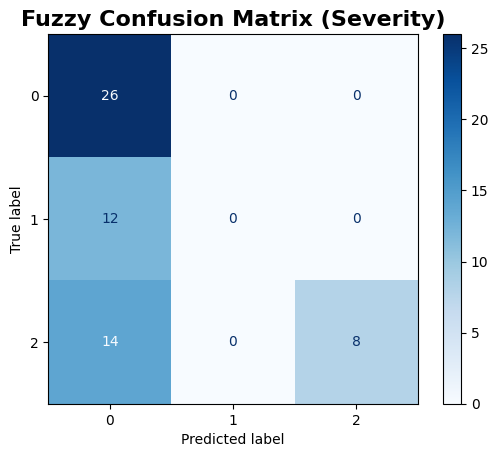

In [107]:
# Severity confusion matrix
cm = confusion_matrix(df["severity"], severity_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Fuzzy Confusion Matrix (Severity)", fontsize=16, fontweight='bold')
plt.show()

In [108]:
# Get the false positives and negatives for severity
FP = np.sum(cm, axis=0) - np.diag(cm)
FN = np.sum(cm, axis=1) - np.diag(cm)

print("False positives:", sum(FP))
print("False negatives:", sum(FN))

False positives: 26
False negatives: 26


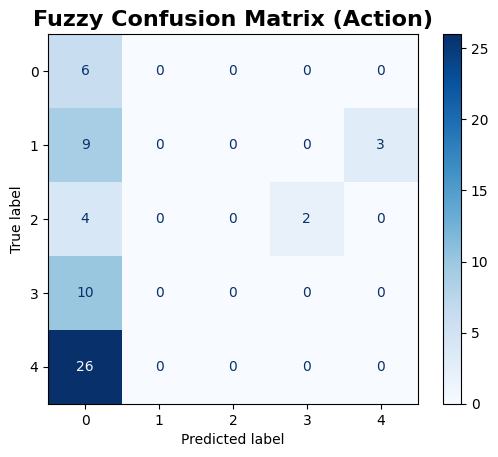

In [109]:
# Action confusion matrix
cm = confusion_matrix(df["action"], action_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Fuzzy Confusion Matrix (Action)", fontsize=16, fontweight='bold')
plt.show()

In [110]:
# Get the false positives and negatives for the action
FP = np.sum(cm, axis=0) - np.diag(cm)
FN = np.sum(cm, axis=1) - np.diag(cm)

print("False positives:", sum(FP))
print("False negatives:", sum(FN))

False positives: 54
False negatives: 54


In [111]:
# Severity classification report
print("\nSeverity Classification Report:")
print(classification_report(df["severity"], severity_pred))


Severity Classification Report:
              precision    recall  f1-score   support

    Moderate       0.50      1.00      0.67        26
      Normal       0.00      0.00      0.00        12
      Severe       1.00      0.36      0.53        22

    accuracy                           0.57        60
   macro avg       0.50      0.45      0.40        60
weighted avg       0.58      0.57      0.48        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [112]:
# Action classification report
print("\nAction Classification Report:")
print(classification_report(df["action"], action_pred, zero_division=False))


Action Classification Report:
                         precision    recall  f1-score   support

CLUTCH_PRESSURE_RECALIB       0.11      1.00      0.20         6
              NO_ACTION       0.00      0.00      0.00        12
               RPM_SYNC       0.00      0.00      0.00         6
    SHIFT_TIMING_ADJUST       0.00      0.00      0.00        10
  TORQUE_REDISTRIBUTION       0.00      0.00      0.00        26

               accuracy                           0.10        60
              macro avg       0.02      0.20      0.04        60
           weighted avg       0.01      0.10      0.02        60



In [113]:
# Weighted F1-Score for severity
severity_f1 = f1_score(df["severity"], severity_pred, average="weighted")
print("Severity F1-score:", np.round(severity_f1, 3))

Severity F1-score: 0.484


In [114]:
# Weighted F1-Score for action
action_f1 = f1_score(df["action"], action_pred, average="weighted")
print("Action F1-score:", np.round(action_f1, 3))

Action F1-score: 0.02


# 7. Membership Functions

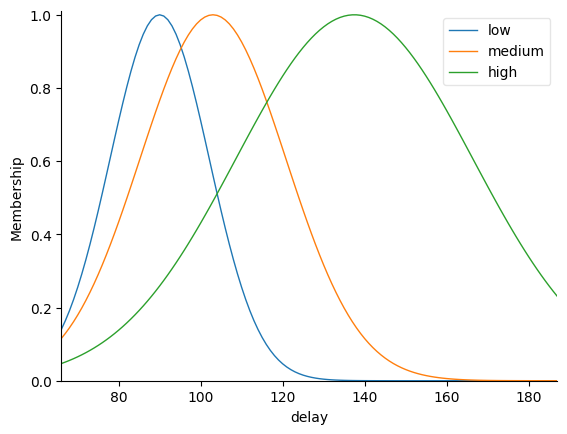

In [115]:
# Delay function
delay.view()

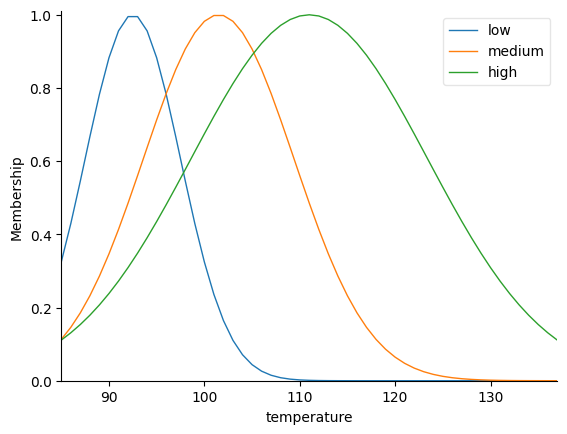

In [116]:
# Temperature function
temperature.view()

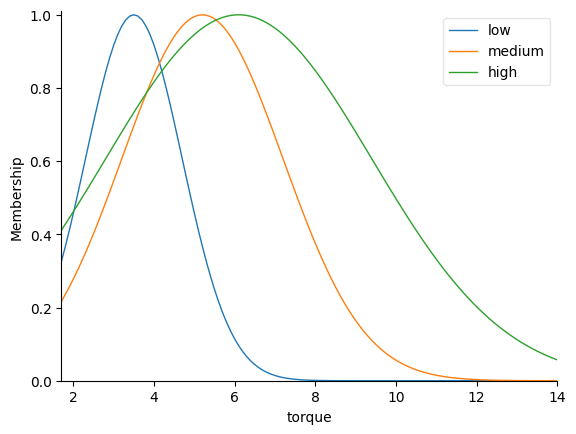

In [117]:
# Torque function
torque.view()

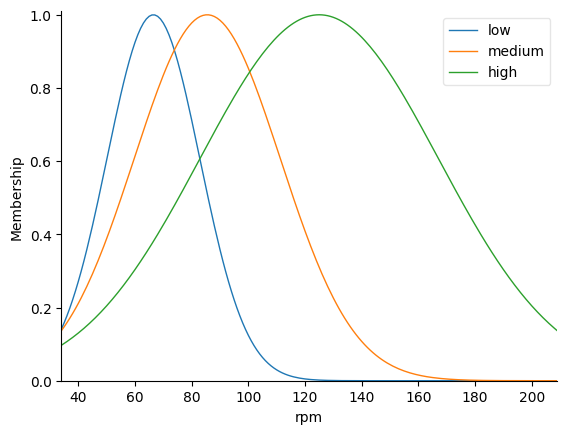

In [118]:
# RPM function
rpm.view()

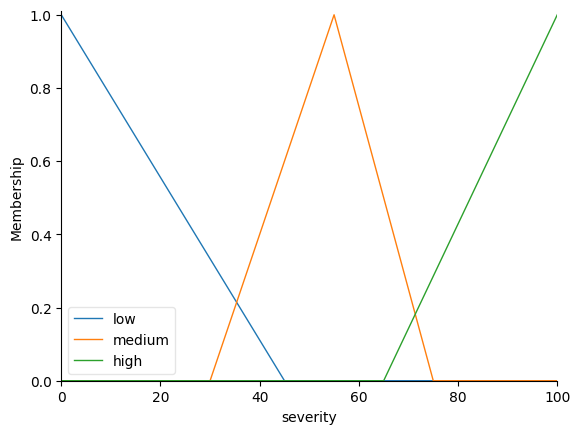

In [119]:
# Severity output function
severity_output.view()

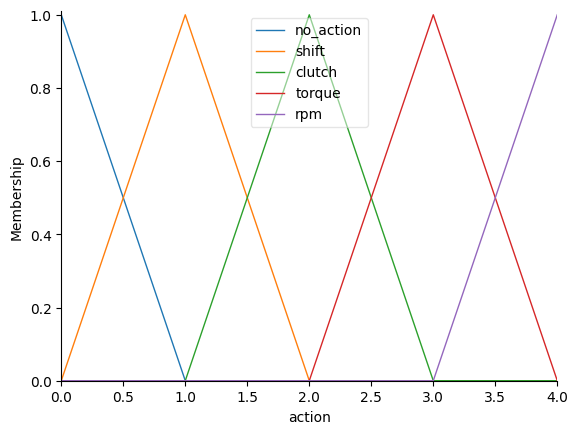

In [120]:
# Action function
action.view()